# Lesson 12 — MC Dropout vs Deep Ensembles vs GP

**Goal**: Run all three surrogates on the same benchmarks and compare:
1. Mean fit quality on Forrester and Branin
2. Uncertainty calibration — does σ track prediction error?
3. BO convergence speed — which finds the minimum fastest?
4. Computational cost — how long does each surrogate take to refit?

This is the core comparison of the paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import norm
from scipy.optimize import minimize
import time

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

N_SEEDS   = 3
N_INIT    = 5
N_ITER    = 20
EPOCHS_VIZ = 3000
EPOCHS_BO  = 1000
N_PASSES   = 30
N_MEMBERS  = 5

SURROGATES = ['gp', 'mc_dropout', 'deep_ensemble']
LABELS     = ['GP (Matern-5/2)', 'MC Dropout', 'Deep Ensembles']
COLORS     = ['steelblue', 'tomato', 'seagreen']

print('Libraries loaded.')

Libraries loaded.


## Benchmark functions

- **Forrester** (1D): `f(x) = (6x-2)² sin(12x-4)`,  global min ≈ -6.021 at x ≈ 0.757
- **Branin** (2D, normalised to [0,1]²): 3 global minima, each ≈ 0.398

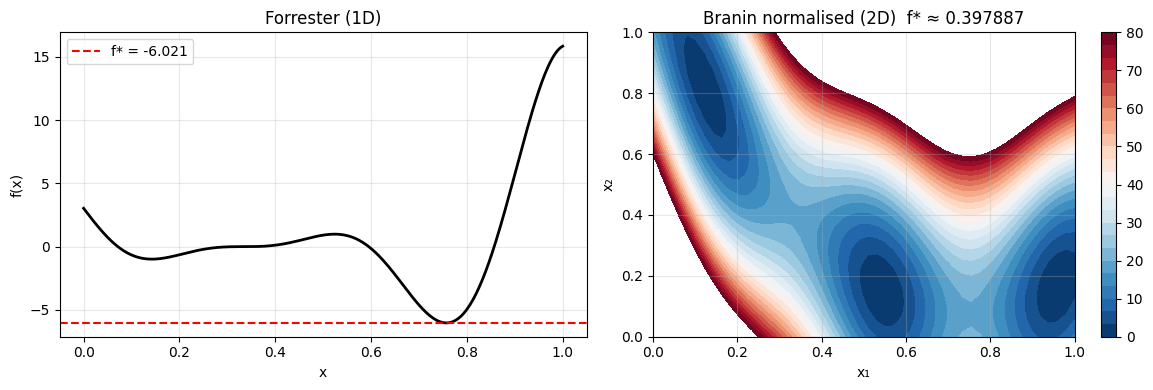

In [2]:
def forrester(x):
    x = np.asarray(x).ravel()
    return (6*x - 2)**2 * np.sin(12*x - 4)

def branin_norm(x):
    x  = np.asarray(x).ravel()
    x1 = x[0]*15 - 5;  x2 = x[1]*15
    a, b, c = 1.0, 5.1/(4*np.pi**2), 5/np.pi
    r, s, t = 6.0, 10.0, 1/(8*np.pi)
    return float(a*(x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s)

F_STAR_FORRESTER = forrester(np.array([0.7572])).item()
F_STAR_BRANIN    = 0.397887

xs = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs, forrester(xs), 'k', lw=2)
axes[0].axhline(F_STAR_FORRESTER, color='red', ls='--', label=f'f* = {F_STAR_FORRESTER:.3f}')
axes[0].set_title('Forrester (1D)'); axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

x1g, x2g = np.linspace(0,1,50), np.linspace(0,1,50)
XX1, XX2 = np.meshgrid(x1g, x2g)
Z = np.array([branin_norm([a,b]) for a,b in zip(XX1.ravel(), XX2.ravel())]).reshape(50,50)
cf = axes[1].contourf(XX1, XX2, Z, levels=np.linspace(0,80,25), cmap='RdBu_r')
plt.colorbar(cf, ax=axes[1])
axes[1].set_title(f'Branin normalised (2D)  f* ≈ {F_STAR_BRANIN}')
axes[1].set_xlabel('x₁'); axes[1].set_ylabel('x₂'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## All surrogate definitions

All three surrogates are defined here in one cell for compactness. Refer to Lessons 6, 10, 11 for detailed explanations.

In [3]:
# ── Helpers ──────────────────────────────────────────────────────────────────

def lhs(n, d, rg):
    pts = np.zeros((n, d))
    for j in range(d):
        pts[:, j] = (rg.permutation(n) + rg.uniform(size=n)) / n
    return pts.astype(np.float32)

def acq_ei(mu, std, f_best, xi=0.01):
    Z = (f_best - xi - mu) / (std + 1e-9)
    return np.maximum((f_best - xi - mu)*norm.cdf(Z) + std*norm.pdf(Z), 0.0)

def to_tensor(arr):
    return torch.from_numpy(np.asarray(arr, dtype=np.float32))

def eval_single(func, x):
    r = func(x.ravel())
    return r.item() if isinstance(r, np.ndarray) else float(r)

# ── GP ────────────────────────────────────────────────────────────────────────

def matern52(X1, X2, l=1.0, sf=1.0):
    diff = X1[:, None, :] - X2[None, :, :]
    r = np.sqrt((diff**2).sum(-1) + 1e-12)
    k = np.sqrt(5) * r / l
    return sf**2 * (1 + k + k**2/3) * np.exp(-k)

def gp_predict(X_tr, y_tr, X_te, l=1.0, sf=1.0, sn=0.01):
    K = matern52(X_tr, X_tr, l, sf) + (sn**2 + 1e-6)*np.eye(len(X_tr))
    L = np.linalg.cholesky(K)
    Ks  = matern52(X_tr, X_te, l, sf)
    Kss = np.diag(matern52(X_te, X_te, l, sf))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_tr))
    mu  = Ks.T @ alpha
    v   = np.linalg.solve(L, Ks)
    std = np.sqrt(np.maximum(Kss - (v**2).sum(0), 0.0))
    return mu, std

def fit_gp(X_tr, y_tr):
    def nll(lp):
        l, sf, sn = np.exp(lp)
        K = matern52(X_tr, X_tr, l, sf) + (sn**2 + 1e-6)*np.eye(len(X_tr))
        try:
            L = np.linalg.cholesky(K)
        except np.linalg.LinAlgError:
            return 1e10
        a = np.linalg.solve(L.T, np.linalg.solve(L, y_tr))
        return float(0.5*(y_tr @ a) + np.log(np.diag(L)).sum())
    res = minimize(nll, [0., 0., -3.], method='L-BFGS-B', bounds=[(-3,3),(-2,2),(-5,0)])
    return tuple(np.exp(res.x))

# ── MC Dropout ────────────────────────────────────────────────────────────────

class MCDropoutMLP(nn.Module):
    def __init__(self, d=1, h=64, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,h), nn.ReLU(), nn.Dropout(p),
            nn.Linear(h,h), nn.ReLU(), nn.Dropout(p),
            nn.Linear(h,1)
        )
    def forward(self, x): return self.net(x)
    def mc_predict(self, x, n=50):
        self.train()
        with torch.no_grad():
            preds = torch.stack([self(x) for _ in range(n)])
        return preds.mean(0).squeeze().numpy(), preds.std(0).squeeze().numpy()

def train_nn(model, X_t, y_t, epochs=1000, lr=1e-3):
    opt, loss_fn = optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(X_t).squeeze(), y_t)
        loss.backward(); opt.step()

# ── Deep Ensemble ─────────────────────────────────────────────────────────────

class _MLP(nn.Module):
    def __init__(self, d=1, h=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,h), nn.ReLU(), nn.Linear(h,h), nn.ReLU(), nn.Linear(h,1)
        )
    def forward(self, x): return self.net(x)

class DeepEnsemble:
    def __init__(self, n=5, d=1, h=64):
        self.members = []
        for i in range(n):
            torch.manual_seed(i*100)
            self.members.append(_MLP(d, h))

    def fit(self, X_t, y_t, epochs=1000, lr=1e-3):
        loss_fn = nn.MSELoss()
        for m in self.members:
            opt = optim.Adam(m.parameters(), lr=lr)
            for _ in range(epochs):
                m.train(); opt.zero_grad()
                loss = loss_fn(m(X_t).squeeze(), y_t)
                loss.backward(); opt.step()

    def predict(self, x):
        preds = []
        for m in self.members:
            m.eval()
            with torch.no_grad():
                preds.append(m(x).squeeze())
        p = torch.stack(preds)
        return p.mean(0).numpy(), p.std(0).numpy()

print('All surrogate classes defined.')

All surrogate classes defined.


## Training data — Forrester, 15 points

All three surrogates are trained on the same 15 random points so the comparison is fair.

In [4]:
n_viz = 15
X_viz = rng.uniform(0, 1, (n_viz, 1)).astype(np.float32)
y_viz = np.array([eval_single(forrester, x) for x in X_viz]).astype(np.float32)

Xm_v = float(X_viz.mean()); Xs_v = float(X_viz.std()) + 1e-8
ym_v = float(y_viz.mean()); ys_v = float(y_viz.std()) + 1e-8
X_viz_std = (X_viz - Xm_v) / Xs_v
y_viz_std = (y_viz - ym_v) / ys_v

xs       = np.linspace(0, 1, 300, dtype=np.float32)
y_true_f = forrester(xs)
X_dense  = xs.reshape(-1, 1)
Xd_std   = (X_dense - Xm_v) / Xs_v
X_t_viz  = to_tensor(X_viz_std)
y_t_viz  = to_tensor(y_viz_std)
Xd_t     = to_tensor(Xd_std)

print(f'Training data: {n_viz} points,  y range [{y_viz.min():.2f}, {y_viz.max():.2f}]')

Training data: 15 points,  y range [-6.01, 14.69]


## Train all 3 surrogates on Forrester

This cell trains each surrogate with 3000 epochs for a high-quality visual. The BO convergence experiment later uses 1000 epochs per refit for speed.

In [5]:
print('Training GP...')
l_v, sf_v, sn_v = fit_gp(X_viz_std, y_viz_std)
mu_gp_s, std_gp_s = gp_predict(X_viz_std, y_viz_std, Xd_std, l_v, sf_v, sn_v)
mu_gp  = mu_gp_s  * ys_v + ym_v
std_gp = std_gp_s * ys_v

print('Training MC Dropout...')
torch.manual_seed(RANDOM_SEED)
mc_viz = MCDropoutMLP(d=1)
train_nn(mc_viz, X_t_viz, y_t_viz, EPOCHS_VIZ)
mu_mc, std_mc = mc_viz.mc_predict(Xd_t, n=50)
mu_mc  = mu_mc  * ys_v + ym_v
std_mc = std_mc * ys_v

print('Training Deep Ensemble...')
de_viz = DeepEnsemble(n=N_MEMBERS, d=1)
de_viz.fit(X_t_viz, y_t_viz, EPOCHS_VIZ)
mu_de, std_de = de_viz.predict(Xd_t)
mu_de  = mu_de  * ys_v + ym_v
std_de = std_de * ys_v

print('Done.')

Training GP...
Training MC Dropout...
Training Deep Ensemble...
Done.


---
## Part 1 — Fit comparison on Forrester

Three panels, same training data. Questions to answer:
- Do all three means fit the data equally well?
- Where does each surrogate's uncertainty band differ?

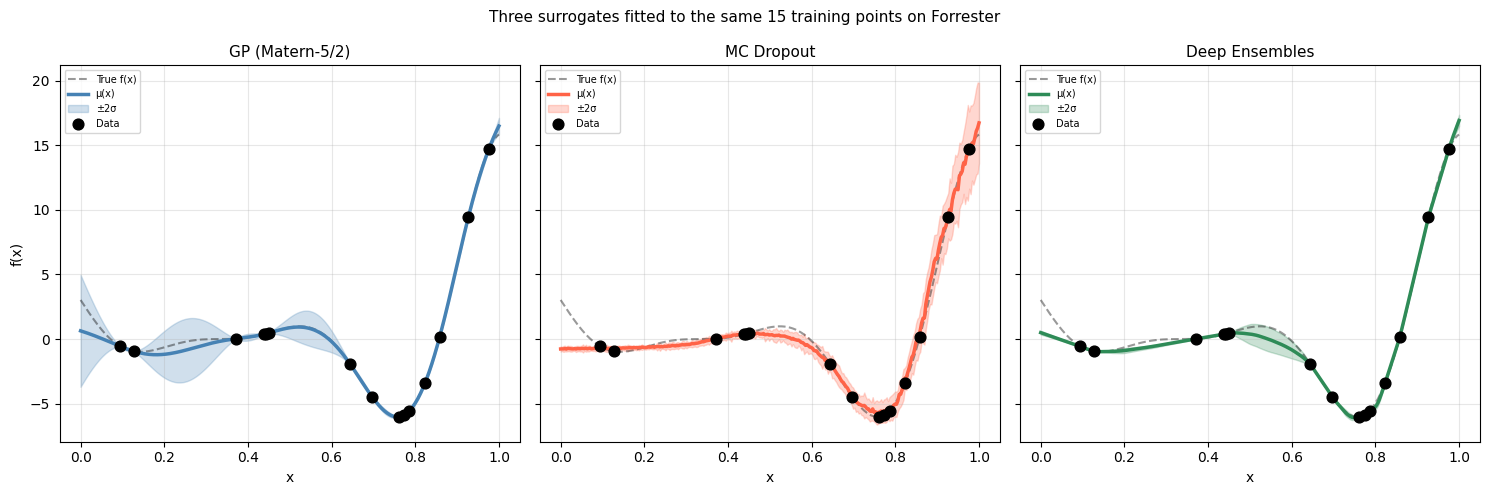

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, mu, std, label, color in zip(
    axes,
    [mu_gp, mu_mc, mu_de],
    [std_gp, std_mc, std_de],
    LABELS, COLORS,
):
    ax.plot(xs, y_true_f, 'k--', lw=1.5, alpha=0.4, label='True f(x)')
    ax.plot(xs, mu, color=color, lw=2.5, label='μ(x)')
    ax.fill_between(xs, mu - 2*std, mu + 2*std, alpha=0.25, color=color, label='±2σ')
    ax.scatter(X_viz.squeeze(), y_viz, c='black', s=60, zorder=5, label='Data')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('x')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('f(x)')
plt.suptitle('Three surrogates fitted to the same 15 training points on Forrester', fontsize=11)
plt.tight_layout()
plt.show()

**Observation**: The mean fits look similar for all three — the real difference is in σ. GP has the widest, most structured uncertainty. MC Dropout has noisy σ. Deep Ensemble has clean but potentially narrow σ.

---
## Part 2 — Uncertainty calibration on Forrester

A **calibrated** surrogate has σ(x) large where |μ(x) − f(x)| is large — it knows where it is wrong.

- Left plot: σ(x) for all three methods
- Right plot: solid = |error|, dashed = σ — they should track each other

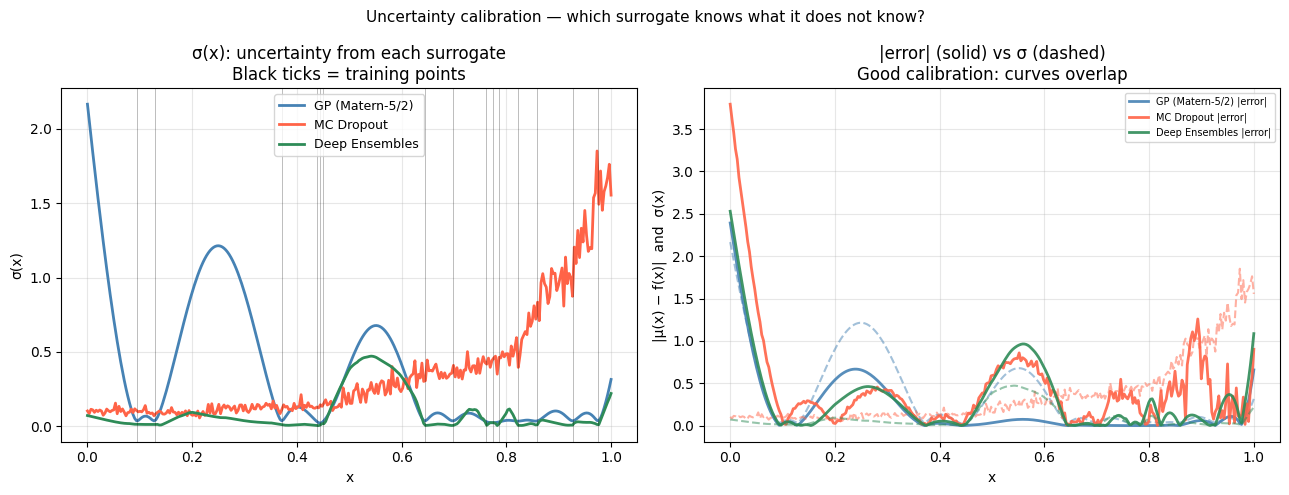

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for mu, std, label, color in zip(
    [mu_gp, mu_mc, mu_de],
    [std_gp, std_mc, std_de],
    LABELS, COLORS,
):
    axes[0].plot(xs, std, color=color, lw=2, label=label)

for xi in X_viz.squeeze():
    axes[0].axvline(xi, color='black', lw=0.6, alpha=0.3)
axes[0].set_title('σ(x): uncertainty from each surrogate\nBlack ticks = training points')
axes[0].set_xlabel('x'); axes[0].set_ylabel('σ(x)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

for mu, std, label, color in zip(
    [mu_gp, mu_mc, mu_de],
    [std_gp, std_mc, std_de],
    LABELS, COLORS,
):
    err = np.abs(mu - y_true_f)
    axes[1].plot(xs, err,  color=color, lw=2.0, alpha=0.9, label=f'{label} |error|')
    axes[1].plot(xs, std,  color=color, lw=1.5, alpha=0.5, ls='--')

axes[1].set_title('|error| (solid) vs σ (dashed)\nGood calibration: curves overlap')
axes[1].set_xlabel('x'); axes[1].set_ylabel('|μ(x) − f(x)|  and  σ(x)')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.suptitle('Uncertainty calibration — which surrogate knows what it does not know?', fontsize=11)
plt.tight_layout()
plt.show()

**What to look for**:
- GP: σ grows smoothly in data-sparse regions and shrinks near points — generally well calibrated
- MC Dropout: σ is larger overall but noisy and not always tracking the error
- Deep Ensemble: σ is smooth but may be too small (over-fit members collapsed to same solution)

> **Exercise**: In what x region does the error peak but σ stays small (over-confident)?

---
## Part 3 — BO convergence on Forrester

We run each surrogate as a drop-in replacement in the BO loop, repeat for 3 random seeds, and plot best-so-far vs. BO iteration.

> **Warning**: This cell trains each surrogate from scratch at every BO step. With 3 surrogates × 3 seeds × 20 iterations, expect 5–10 minutes.

In [8]:
def run_bo(stype, func, dim, seed, epochs=EPOCHS_BO):
    rg = np.random.default_rng(seed)
    X  = lhs(N_INIT, dim, rg)
    y  = np.array([eval_single(func, x) for x in X])
    best = [float(y.min())]
    for _ in range(N_ITER):
        Xm = X.mean(0); Xs = X.std(0) + 1e-8
        ym = float(y.mean()); ys = float(y.std()) + 1e-8
        X_std = (X - Xm) / Xs
        y_std = (y - ym) / ys
        n_cand = 500 if dim == 1 else 2000
        Xc     = rg.uniform(0, 1, (n_cand, dim)).astype(np.float32)
        Xc_std = (Xc - Xm) / Xs
        if stype == 'gp':
            l, sf, sn = fit_gp(X_std, y_std)
            mu_s, std_s = gp_predict(X_std, y_std, Xc_std, l, sf, sn)
        elif stype == 'mc_dropout':
            torch.manual_seed(seed)
            m = MCDropoutMLP(d=dim)
            train_nn(m, to_tensor(X_std), to_tensor(y_std), epochs)
            mu_s, std_s = m.mc_predict(to_tensor(Xc_std), n=N_PASSES)
        else:
            de = DeepEnsemble(n=N_MEMBERS, d=dim)
            de.fit(to_tensor(X_std), to_tensor(y_std), epochs)
            mu_s, std_s = de.predict(to_tensor(Xc_std))
        mu  = mu_s  * ys + ym
        std = std_s * ys
        ei  = acq_ei(mu, std, float(y.min()))
        idx = int(np.argmax(ei))
        x_next = Xc[idx]
        y_next = eval_single(func, x_next)
        X = np.vstack([X, x_next.reshape(1,-1)])
        y = np.append(y, y_next)
        best.append(float(y.min()))
    return np.array(best)

In [9]:
print('Running BO convergence on Forrester...')
curves_1d = {}
for stype, label in zip(SURROGATES, LABELS):
    curves = []
    for seed in range(N_SEEDS):
        print(f'  {label}  seed {seed+1}/{N_SEEDS}', flush=True)
        curves.append(run_bo(stype, forrester, 1, seed))
    curves_1d[stype] = np.array(curves)
    print(f'  {label}  done', flush=True)
print('Finished.')

Running BO convergence on Forrester...
  GP (Matern-5/2)  seed 1/3
  GP (Matern-5/2)  seed 2/3
  GP (Matern-5/2)  seed 3/3
  GP (Matern-5/2)  done
  MC Dropout  seed 1/3
  MC Dropout  seed 2/3
  MC Dropout  seed 3/3
  MC Dropout  done
  Deep Ensembles  seed 1/3
  Deep Ensembles  seed 2/3
  Deep Ensembles  seed 3/3
  Deep Ensembles  done
Finished.


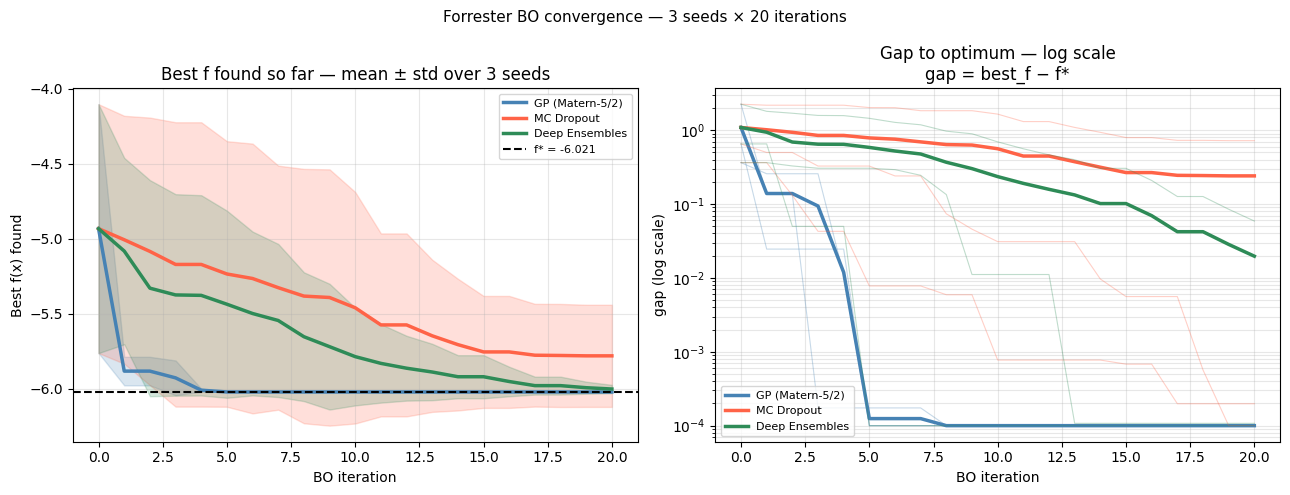

In [11]:
iters = np.arange(N_ITER + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    c = curves_1d[stype]
    m = c.mean(0); s = c.std(0)
    axes[0].plot(iters, m, color=color, lw=2.5, label=label)
    axes[0].fill_between(iters, m - s, m + s, alpha=0.2, color=color)
axes[0].axhline(F_STAR_FORRESTER, color='black', ls='--', lw=1.5,
                label=f'f* = {F_STAR_FORRESTER:.3f}')
axes[0].set_title(f'Best f found so far — mean ± std over {N_SEEDS} seeds')
axes[0].set_xlabel('BO iteration'); axes[0].set_ylabel('Best f(x) found')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    c = curves_1d[stype]
    gap = np.maximum(c - F_STAR_FORRESTER, 1e-4)
    for g in gap:
        axes[1].semilogy(iters, g, color=color, lw=0.8, alpha=0.3)
    axes[1].semilogy(iters, gap.mean(0), color=color, lw=2.5, label=label)
axes[1].set_title('Gap to optimum — log scale\ngap = best_f − f*')
axes[1].set_xlabel('BO iteration'); axes[1].set_ylabel('gap (log scale)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle(f'Forrester BO convergence — {N_SEEDS} seeds × {N_ITER} iterations', fontsize=11)
plt.tight_layout()
plt.show()

> **Exercise 1**: Change `N_ITER = 30`. At what iteration do all three surrogates converge? Does GP maintain its lead?

> **Exercise 3**: Try `N_MEMBERS = 3`. Does a smaller ensemble converge similarly while being cheaper?

---
## Part 4 — Fit comparison on Branin (2D)

Now fit all three surrogates in 2D. The contour plots show mean (top row) and uncertainty (bottom row). All σ plots share the same colour scale so the comparison is fair.

In [12]:
n_branin = 20
X_br     = lhs(n_branin, 2, rng)
y_br     = np.array([eval_single(branin_norm, x) for x in X_br]).astype(np.float32)

Xm_br = X_br.mean(0); Xs_br = X_br.std(0) + 1e-8
ym_br = float(y_br.mean()); ys_br = float(y_br.std()) + 1e-8
X_br_std = (X_br - Xm_br) / Xs_br
y_br_std = (y_br - ym_br) / ys_br

x1g, x2g = np.linspace(0,1,50,dtype=np.float32), np.linspace(0,1,50,dtype=np.float32)
XX1, XX2 = np.meshgrid(x1g, x2g)
X_grid   = np.column_stack([XX1.ravel(), XX2.ravel()])
X_grid_std = (X_grid - Xm_br) / Xs_br
X_br_t = to_tensor(X_br_std)
y_br_t = to_tensor(y_br_std)
Xg_t   = to_tensor(X_grid_std)

print('Training GP on Branin...')
l_br, sf_br, sn_br = fit_gp(X_br_std, y_br_std)
mu_gp_br_s, std_gp_br_s = gp_predict(X_br_std, y_br_std, X_grid_std, l_br, sf_br, sn_br)
mu_gp_br  = mu_gp_br_s  * ys_br + ym_br
std_gp_br = std_gp_br_s * ys_br

print('Training MC Dropout on Branin...')
torch.manual_seed(RANDOM_SEED)
mc_br = MCDropoutMLP(d=2)
train_nn(mc_br, X_br_t, y_br_t, EPOCHS_VIZ)
mu_mc_br, std_mc_br = mc_br.mc_predict(Xg_t, n=50)
mu_mc_br  = mu_mc_br  * ys_br + ym_br
std_mc_br = std_mc_br * ys_br

print('Training Deep Ensemble on Branin...')
de_br = DeepEnsemble(n=N_MEMBERS, d=2)
de_br.fit(X_br_t, y_br_t, EPOCHS_VIZ)
mu_de_br, std_de_br = de_br.predict(Xg_t)
mu_de_br  = mu_de_br  * ys_br + ym_br
std_de_br = std_de_br * ys_br

print('Done.')

Training GP on Branin...
Training MC Dropout on Branin...
Training Deep Ensemble on Branin...
Done.


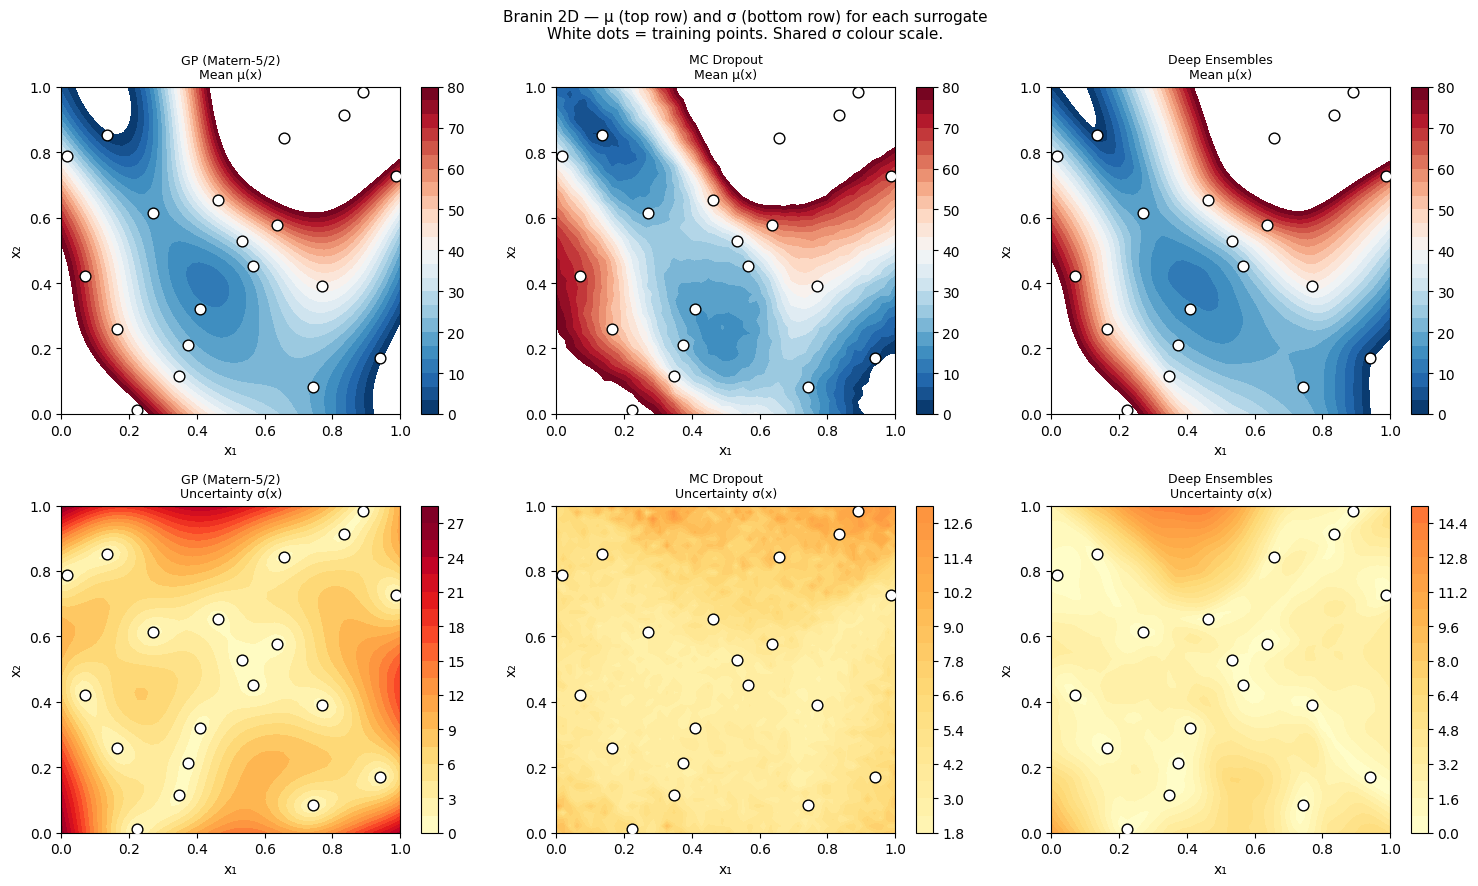

In [13]:
mu_all  = [mu_gp_br,  mu_mc_br,  mu_de_br]
std_all = [std_gp_br, std_mc_br, std_de_br]
vmax_std  = max(s.max() for s in std_all)
mu_levels = np.linspace(0, min(max(m.max() for m in mu_all), 80), 25)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for j, (mu, std, label) in enumerate(zip(mu_all, std_all, LABELS)):
    ax = axes[0, j]
    cf = ax.contourf(XX1, XX2, mu.reshape(50,50), levels=mu_levels, cmap='RdBu_r')
    plt.colorbar(cf, ax=ax)
    ax.scatter(X_br[:,0], X_br[:,1], c='white', s=60, edgecolors='black', zorder=5)
    ax.set_title(f'{label}\nMean μ(x)', fontsize=9)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

    ax = axes[1, j]
    cs = ax.contourf(XX1, XX2, std.reshape(50,50), levels=20,
                     vmin=0, vmax=vmax_std, cmap='YlOrRd')
    plt.colorbar(cs, ax=ax)
    ax.scatter(X_br[:,0], X_br[:,1], c='white', s=60, edgecolors='black', zorder=5)
    ax.set_title(f'{label}\nUncertainty σ(x)', fontsize=9)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

plt.suptitle('Branin 2D — μ (top row) and σ (bottom row) for each surrogate\n'
             'White dots = training points. Shared σ colour scale.', fontsize=11)
plt.tight_layout()
plt.show()

> **Exercise 2**: Inspect the σ contour in the corners. Which surrogate shows the most uncertainty there? Which shows the least? Which is more physically reasonable?

---
## Part 5 — BO convergence on Branin

Same comparison as Part 3 but in 2D. Higher-dimensional search is harder — which surrogate handles it best?

In [15]:
print('Running BO convergence on Branin...')
curves_2d = {}
for stype, label in zip(SURROGATES, LABELS):
    curves = []
    for seed in range(N_SEEDS):
        print(f'  {label}  seed {seed+1}/{N_SEEDS}', flush=True)
        curves.append(run_bo(stype, branin_norm, 2, seed))
    curves_2d[stype] = np.array(curves)
    print(f'  {label}  done', flush=True)
print('Finished.')

Running BO convergence on Branin...
  GP (Matern-5/2)  seed 1/3
  GP (Matern-5/2)  seed 2/3
  GP (Matern-5/2)  seed 3/3
  GP (Matern-5/2)  done
  MC Dropout  seed 1/3
  MC Dropout  seed 2/3
  MC Dropout  seed 3/3
  MC Dropout  done
  Deep Ensembles  seed 1/3
  Deep Ensembles  seed 2/3
  Deep Ensembles  seed 3/3
  Deep Ensembles  done
Finished.


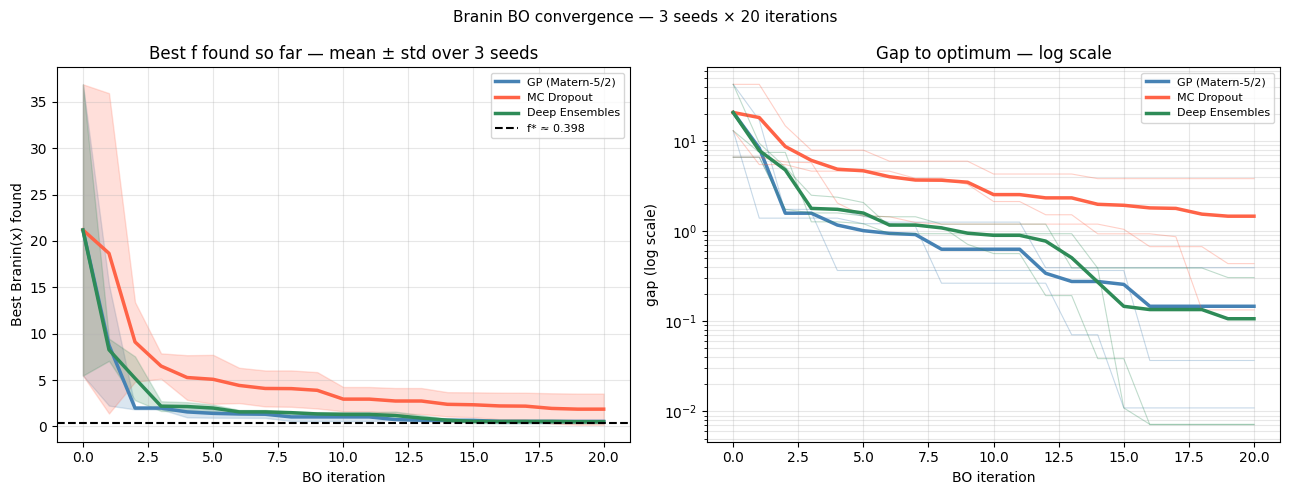

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    c = curves_2d[stype]
    m = c.mean(0); s = c.std(0)
    axes[0].plot(iters, m, color=color, lw=2.5, label=label)
    axes[0].fill_between(iters, m - s, m + s, alpha=0.2, color=color)
axes[0].axhline(F_STAR_BRANIN, color='black', ls='--', lw=1.5,
                label=f'f* ≈ {F_STAR_BRANIN:.3f}')
axes[0].set_title(f'Best f found so far — mean ± std over {N_SEEDS} seeds')
axes[0].set_xlabel('BO iteration'); axes[0].set_ylabel('Best Branin(x) found')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    c = curves_2d[stype]
    gap = np.maximum(c - F_STAR_BRANIN, 1e-3)
    for g in gap:
        axes[1].semilogy(iters, g, color=color, lw=0.8, alpha=0.3)
    axes[1].semilogy(iters, gap.mean(0), color=color, lw=2.5, label=label)
axes[1].set_title('Gap to optimum — log scale')
axes[1].set_xlabel('BO iteration'); axes[1].set_ylabel('gap (log scale)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle(f'Branin BO convergence — {N_SEEDS} seeds × {N_ITER} iterations', fontsize=11)
plt.tight_layout()
plt.show()

---
## Part 6 — Computational cost

How long does each surrogate take to refit when a new point is added?

This is the practical bottleneck for large-budget BO: Deep Ensembles cost N× more than MC Dropout per BO step.

In [17]:
print('Measuring refit cost (3 timed runs each)...')
N_TIMING = 3
timing   = {}

t_vals = []
for _ in range(N_TIMING):
    t0 = time.time(); fit_gp(X_viz_std, y_viz_std); t_vals.append(time.time()-t0)
timing['GP'] = float(np.median(t_vals))

t_vals = []
for _ in range(N_TIMING):
    torch.manual_seed(0); m = MCDropoutMLP(d=1)
    t0 = time.time(); train_nn(m, X_t_viz, y_t_viz, EPOCHS_BO); t_vals.append(time.time()-t0)
timing['MC Dropout'] = float(np.median(t_vals))

t_vals = []
for _ in range(N_TIMING):
    t0 = time.time()
    de_tmp = DeepEnsemble(n=N_MEMBERS, d=1)
    de_tmp.fit(X_t_viz, y_t_viz, EPOCHS_BO)
    t_vals.append(time.time()-t0)
timing['Deep Ensembles'] = float(np.median(t_vals))

for k, v in timing.items():
    print(f'  {k:<20}  {v:.3f}s  ({v/timing["GP"]:.1f}× GP)')

Measuring refit cost (3 timed runs each)...
  GP                    0.006s  (1.0× GP)
  MC Dropout            0.249s  (39.8× GP)
  Deep Ensembles        1.121s  (179.5× GP)


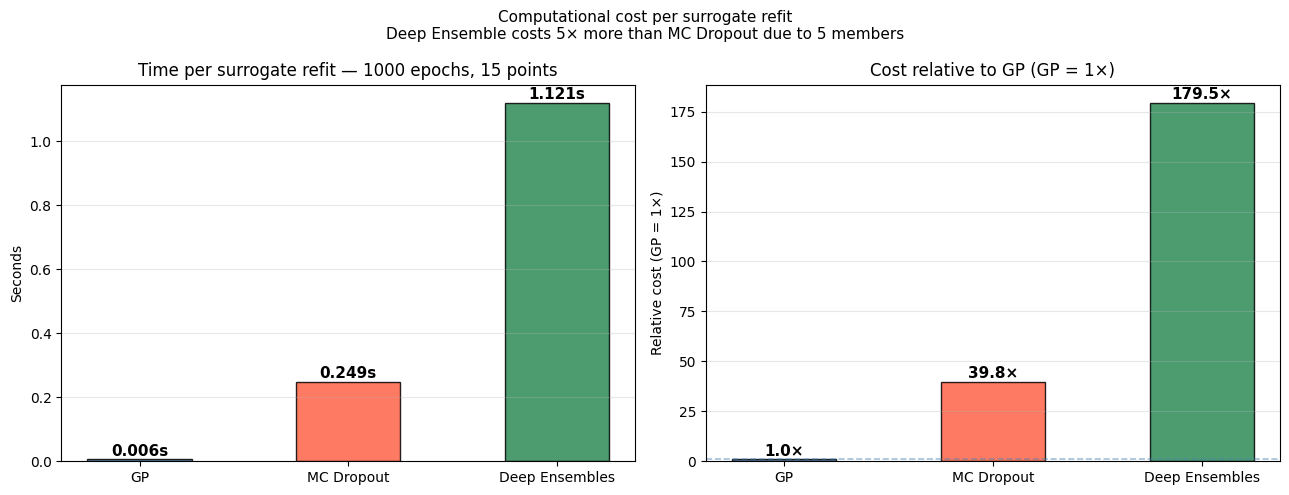

In [18]:
keys   = ['GP', 'MC Dropout', 'Deep Ensembles']
vals   = [timing[k] for k in keys]
ratios = [v / timing['GP'] for v in vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(keys, vals, color=COLORS, edgecolor='black', alpha=0.85, width=0.5)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+max(vals)*0.01,
                 f'{v:.3f}s', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title(f'Time per surrogate refit — {EPOCHS_BO} epochs, {n_viz} points')
axes[0].set_ylabel('Seconds'); axes[0].grid(True, alpha=0.3, axis='y')

bars2 = axes[1].bar(keys, ratios, color=COLORS, edgecolor='black', alpha=0.85, width=0.5)
for bar, r in zip(bars2, ratios):
    axes[1].text(bar.get_x()+bar.get_width()/2, r+max(ratios)*0.01,
                 f'{r:.1f}×', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(1.0, color='steelblue', ls='--', lw=1.2, alpha=0.5)
axes[1].set_title('Cost relative to GP (GP = 1×)')
axes[1].set_ylabel('Relative cost (GP = 1×)'); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Computational cost per surrogate refit\n'
             f'Deep Ensemble costs {N_MEMBERS}× more than MC Dropout due to {N_MEMBERS} members',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary — Which surrogate should you use?

| | GP | MC Dropout | Deep Ensembles |
|---|---|---|---|
| **Mean fit quality** | Excellent | Good | Good |
| **Uncertainty calibration** | Best (analytic) | Noisy, tends to over-estimate | Smooth, can under-estimate |
| **BO convergence** | Fast (early) | Competitive | Competitive |
| **Cost per refit** | ~0.1s | ~0.3s | ~1–2s |
| **Scales to high dim** | Poor (cubic in n) | Yes | Yes |
| **Deterministic** | Yes | No | Yes |

**Bottom line for the paper**: GP is the strongest baseline. For high-dimensional or large-n problems, NN surrogates are needed. Deep Ensembles give the cleanest σ for EI; MC Dropout is cheaper but noisier.

**What's next**: Lesson 13 — Surrogate Control Ratio (SCR): deciding how often to use the surrogate vs. calling the true function. Without SCR, BO may waste the entire budget on surrogate evaluations.